In [ ]:
# === IMPORT REQUIRED LIBRARIES ===
# Import necessary modules for data structures, calculations, file I/O, visualization, and random operations

from dataclasses import dataclass  # For creating data classes with minimal boilerplate
from collections import defaultdict  # For creating dictionaries with default values
import cmath  # Complex math functions
from math import sqrt  # Square root function
import random  # Random number generation
import json  # JSON file I/O
import time  # Timing code execution
import statistics as stats  # Statistical calculations
import matplotlib.pyplot as plt  # Plotting library
from pathlib import Path  # Object-oriented file paths

# Set random seed for reproducibility of random Clifford generation
random.seed(42)

# Tolerance value for floating point comparisons (treat values below this as zero)
TOL = 1e-10

In [ ]:
# === PAULI BLADE CLASS ===
# Represents a basis element in Clifford algebra as a phase and bitmask (e_J)
# phase: 0,1,2,3 represents 1, i, -1, -i respectively
# mask: bitmask indicating which basis elements e_1, e_2, ... are included in the product

@dataclass(frozen=True)
class PauliBlade:
    phase: int  # 0,1,2,3 represents 1,i,-1,-i
    mask: int   # bitmask for e_J

    # Returns the grade (number of basis elements in this blade)
    def grade(self) -> int:
        return self.mask.bit_count()

    # Multiply two Pauli blades together using geometric product
    # Handles phase changes from anticommutation relations
    def __mul__(self, other: "PauliBlade") -> "PauliBlade":
        # Calculate parity from swapping basis elements
        parity = swap_parity(self.mask, other.mask)

        # Combine phases and apply parity correction
        new_phase = (self.phase + other.phase + 2 * parity) % 4
        # XOR masks to compute the product basis element
        new_mask = self.mask ^ other.mask

        return PauliBlade(new_phase, new_mask)

    # Negate the blade (multiply by -1)
    def __neg__(self):
        return PauliBlade((self.phase + 2) % 4, self.mask)

    def __repr__(self):
        return f"PauliBlade(phase={self.phase}, mask={self.mask})"
 

# === SWAP PARITY HELPER FUNCTION ===
# Calculates the parity (sign) resulting from reordering basis elements
# Based on how many pairs of basis elements need to be swapped
def swap_parity(mask_left: int, mask_right: int) -> int:
    parity = 0
    m = mask_left

    # For each basis element in the left mask
    while m:
        # Extract the lowest set bit
        bit = m & -m
        pos = bit.bit_length() - 1

        # Count how many basis elements in right mask are lower than this position
        lower_bits = mask_right & ((1 << pos) - 1)
        # Each swap with a lower element contributes 1 to parity
        parity ^= lower_bits.bit_count() & 1

        # Remove the processed bit
        m ^= bit

    return parity

In [ ]:
# === PHASE VALUE MAPPING ===
# Maps phase encoding (0,1,2,3) to complex numbers (1, i, -1, -i)
PHASE_VALUE = {
    0: 1,      # phase 0 = 1
    1: 1j,     # phase 1 = i
    2: -1,     # phase 2 = -1
    3: -1j,    # phase 3 = -i
}


# === BLADE CANONICALIZATION ===
# Canonicalizes a blade by separating phase from the basis element
# Returns (canonical_blade, phase_coefficient) where canonical_blade has phase=0
def canonicalize_blade(blade: PauliBlade):
    key = PauliBlade(0, blade.mask)  # Basis element with no phase
    coeff = PHASE_VALUE[blade.phase]  # Extract phase as complex coefficient
    return key, coeff


# === MULTIVECTOR CLASS ===
# Represents a linear combination of Pauli blades with complex coefficients
# A multivector is a general element of the Clifford algebra
@dataclass
class Multivector:
    coeffs: dict[PauliBlade, complex]  # Dictionary mapping blades to complex coefficients

    # Post-initialization processing: canonicalize all blades
    def __post_init__(self):
        result = defaultdict(complex)

        # Combine terms with the same canonical blade
        for blade, coeff in self.coeffs.items():
            key, phase_coeff = canonicalize_blade(blade)
            result[key] += complex(coeff) * phase_coeff

        self.coeffs = dict(result)
        self.clean()  # Remove near-zero terms

    # Remove terms with coefficients below tolerance threshold
    def clean(self):
        self.coeffs = {
            blade: coeff
            for blade, coeff in self.coeffs.items()
            if abs(coeff) > TOL
        }
        return self

    # Add two multivectors
    def __add__(self, other: "Multivector") -> "Multivector":
        result = defaultdict(complex)

        for blade, coeff in self.coeffs.items():
            result[blade] += coeff

        for blade, coeff in other.coeffs.items():
            result[blade] += coeff

        return Multivector(dict(result))

    # Negate a multivector (multiply by -1)
    def __neg__(self) -> "Multivector":
        return Multivector({
            blade: -coeff
            for blade, coeff in self.coeffs.items()
        })

    # Subtract two multivectors
    def __sub__(self, other: "Multivector") -> "Multivector":
        return self + (-other)

    # Multiply a multivector by a scalar or another multivector
    def __mul__(self, other):
        # Scalar multiplication: multiply all coefficients
        if isinstance(other, (int, float, complex)):
            return Multivector({
                blade: other * coeff
                for blade, coeff in self.coeffs.items()
            })

        # Multivector multiplication: geometric product of all blade pairs
        if isinstance(other, Multivector):
            result = defaultdict(complex)

            # Multiply each term of self with each term of other
            for b1, c1 in self.coeffs.items():
                for b2, c2 in other.coeffs.items():
                    # Compute blade product using Clifford algebra rules
                    product_blade = b1 * b2
                    key, phase_coeff = canonicalize_blade(product_blade)
                    # Accumulate coefficient
                    result[key] += c1 * c2 * phase_coeff

            return Multivector(dict(result))

        return NotImplemented

    # Right multiplication (for scalar * multivector)
    def __rmul__(self, other):
        if isinstance(other, (int, float, complex)):
            return self * other

        return NotImplemented

    # Support size: number of distinct basis elements in this multivector
    def sigma(self) -> int:
        return len(self.coeffs)

    # Check if multivector is zero
    def is_zero(self) -> bool:
        return self.sigma() == 0

    def __repr__(self):
        return f"Multivector({self.coeffs})"
    

# === MULTIVECTOR HELPER FUNCTIONS ===

# Create a multivector from a single blade with a coefficient
def blade_mv(blade: PauliBlade, coeff=1) -> Multivector:
    return Multivector({blade: coeff})


# Create a scalar multivector (complex number)
def scalar_mv(x: complex) -> Multivector:
    return Multivector({PauliBlade(0, 0): x})


# Create the identity multivector (scalar 1)
def identity_mv() -> Multivector:
    return scalar_mv(1)

# Create a rotor from a blade (normalized exponential)
# rotor(b) = (1 + b) / sqrt(2) for b^2 = -1
def rotor(blade):
    return (identity_mv() + blade_mv(blade))*(1 / sqrt(2))

In [ ]:
# === BLADE SQUARE SIGN ===
# Determines whether a blade e_J squares to +1 or -1
# For a blade of grade r: (e_J)^2 = (-1)^(r(r-1)/2)
def blade_square_sign(mask: int) -> int:
    """
    Returns +1 or -1 for (e_J)^2.
    """
    r = mask.bit_count()  # Grade of the blade
    # Calculate exponent: r(r-1)/2 mod 2
    exponent = (r * (r - 1) // 2) % 2
    return -1 if exponent == 1 else 1


# === CANONICAL NEGATIVE BLADE ===
# Selects a representative from each pair ±b such that the blade squares to -1
# This is needed to use the blade as a rotor (only works with negative-square blades)
def canonical_negative_blade(mask: int) -> PauliBlade:
    """
    Returns either e_J or i e_J, chosen so that its square is -1.
    If e_J squares to -1, return e_J. Otherwise return i*e_J (which squares to -1).
    """
    if blade_square_sign(mask) == -1:
        return PauliBlade(0, mask)  # e_J (square = -1)
    else:
        return PauliBlade(1, mask)  # i e_J (square = -1)
    

# === GENERATE P_MINUS ===
# Generates all representatives of pairs ±b where b^2 = -1
# This set is used for the Clifford decomposition algorithm
def generate_P_minus(n: int) -> list[PauliBlade]:
    """
    Generates one representative of each pair ±b in P_n^-.
    Excludes the scalar case (empty set J).
    P_n^- is the set of all non-scalar basis elements that square to -1.
    
    Args:
        n: Dimension parameter (algebras have dimension 2n)
    
    Returns:
        List of canonical negative blades
    """
    p = 2 * n  # Total number of basis elements
    blades = []

    # Iterate through all non-scalar masks (1 to 2^p - 1)
    for mask in range(1, 1 << p):
        blades.append(canonical_negative_blade(mask))

    return blades

In [ ]:
# === RANDOM CLIFFORD GENERATOR ===
# Creates a random Clifford element by multiplying random rotors
def random_clifford(Pminus, length):
    """
    Generate a random Clifford group element by multiplying 'length' random rotors.
    
    Args:
        Pminus: List of blades that square to -1 (used to create rotors)
        length: Number of rotor multiplications to perform
    
    Returns:
        (A, chosen): The resulting Clifford element A and the list of chosen rotors
    """
    A = identity_mv()  # Start with identity
    chosen = []

    # Multiply by 'length' random rotors
    for _ in range(length):
        b = random.choice(Pminus)  # Pick random blade
        sign = random.choice([1, -1])  # Randomly choose ±b

        if sign == -1:
            b = -b

        chosen.append(b)
        A = A * rotor(b)  # Multiply by rotor(b)

    return A, chosen


# === GREEDY DECOMPOSITION STEP ===
# Single step of the greedy algorithm: find the rotor that minimizes support size
def greedy_step(A, Pminus):
    """
    Find the best rotor (b) to multiply by that minimizes the support size of the result.
    Tests all possible blades (±b) and returns the one that produces smallest sigma.
    
    Args:
        A: Current multivector to decompose
        Pminus: Set of negative-square blades
    
    Returns:
        (best_b, best_A): The chosen blade and the resulting multivector
    """
    best_b = None
    best_A = None
    best_sigma = float("inf")

    # Try each blade in Pminus and its negation
    for b in Pminus:
        for candidate_b in (b, -b):
            # Compute rotor(−b) * A (multiplication from the left)
            candidate = rotor(-candidate_b)*A
            s = candidate.sigma()  # Compute support size

            # Keep track of the best option
            if s < best_sigma:
                best_sigma = s
                best_b = candidate_b
                best_A = candidate

    return best_b, best_A


# === GREEDY DECOMPOSITION ===
# Iteratively decomposes a Clifford element by greedily minimizing support size
def greedy_decompose(A, Pminus, max_steps=1000):
    """
    Decompose a Clifford element into a product of rotors using greedy algorithm.
    At each step, finds the rotor that minimizes the support size (number of terms).
    Terminates when support size reaches 1 (scalar, done) or max_steps exceeded.
    
    Args:
        A: The Clifford element to decompose
        Pminus: Set of negative-square blades
        max_steps: Maximum iterations (safety limit)
    
    Returns:
        (decomposition, sigmas): List of rotor blades and remaining scalar,
                                 and list of support sizes at each step
    """
    decomposition = []
    sigmas = [A.sigma()]  # Track support size at each step

    # Iteratively reduce support size
    while A.sigma() != 1 and len(decomposition) < max_steps:
        b, A = greedy_step(A, Pminus)  # Find and apply best rotor
        decomposition.append(b)
        sigmas.append(A.sigma())

    # Add the final scalar term
    decomposition.append(A)
    return decomposition, sigmas


# === RECONSTRUCTION CHECK ===
# Verify that the decomposition correctly reconstructs the original element
def check_reconstruction(original, decomp):
    """
    Verify that multiplying the decomposition factors gives back the original.
    
    Args:
        original: Original Clifford element
        decomp: List of rotors and final scalar
    
    Returns:
        Boolean indicating whether reconstruction matches (within tolerance)
    """
    A = identity_mv()

    # Multiply all rotor terms (all but the last)
    for b in decomp[:-1]:
        A = A * rotor(b)

    # Multiply by final scalar term
    A = A * decomp[-1]

    # Check if we recovered the original
    return (A - original).sigma() == 0

In [ ]:
# === EXPERIMENT PARAMETERS ===
N = 100  # Number of trials per (n, L) pair
L = 20   # Maximum rotor length to test
n_values = range(1, 5)  # Clifford algebra dimensions to test (1 through 4)

# Save metadata for reference
metadata = {
    "N": N,
    "L": L,
    "n_values": list(n_values),
}

with open("metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)


# === SERIALIZATION FUNCTIONS ===
# Convert Python objects to JSON-serializable dictionaries

def serialize_blade(b):
    """Convert a PauliBlade to JSON-compatible format."""
    return {
        "type": "blade",
        "phase": b.phase,
        "mask": b.mask
    }


def serialize_mv(A):
    """Convert a Multivector to JSON-compatible format."""
    return {
        "type": "multivector",
        "terms": [
            {
                "phase": blade.phase,
                "mask": blade.mask,
                "coeff_real": coeff.real,
                "coeff_imag": coeff.imag
            }
            for blade, coeff in A.coeffs.items()
        ]
    }


# === MAIN EXPERIMENT LOOP ===
# Run the greedy decomposition algorithm on random Clifford elements

with open("experiment_data.jsonl", "w") as f:

    # Iterate over different algebra dimensions
    for n in n_values:

        print(f"n = {n}")

        # Generate the set of negative-square blades for this dimension
        Pminus = generate_P_minus(n)

        # Iterate over different initial rotor lengths
        for l in range(1, L + 1):

            print(f"   length = {l}")

            # Run N trials for this (n, L) combination
            for trial in range(N):

                # Generate a random Clifford element using L random rotors
                original_clifford, original_generators = random_clifford(
                    Pminus,
                    length=l
                )

                # Time the greedy decomposition algorithm
                start = time.perf_counter()

                computed_decomp, sigmas = greedy_decompose(
                    original_clifford,
                    Pminus
                )

                runtime = time.perf_counter() - start

                # Verify the decomposition is correct
                reconstruction_ok = check_reconstruction(original_clifford, computed_decomp)

                # Record all data for this trial
                record = {
                    # Experiment parameters
                    "n": n,
                    "initial_length": l,
                    "trial": trial,

                    # The random rotors used to generate the original Clifford element
                    "initial_decomposition": [
                        serialize_blade(b)
                        for b in original_generators
                    ],

                    # The rotor blades computed by greedy algorithm and final scalar
                    "computed_decomposition": [
                        *[
                            serialize_blade(b)
                            for b in computed_decomp[:-1]
                        ],
                        serialize_mv(computed_decomp[-1])
                    ],

                    # Support sizes at each iteration (for tracking convergence)
                    "sigmas": sigmas,

                    # Number of rotor factors in the decomposition
                    "decomposition_length": len(computed_decomp) - 1,

                    # Whether the algorithm reached a scalar (convergence)
                    "terminated": sigmas[-1] == 1,

                    # Whether reconstruction verified correctly
                    "reconstruction_ok": reconstruction_ok,

                    # Runtime for this trial
                    "runtime_seconds": runtime
                }

                # Write record to JSONL file (one JSON per line)
                f.write(json.dumps(record) + "\n")
                f.flush()  # Flush to disk immediately for safety

n = 1
   length = 1
   length = 2
   length = 3
   length = 4
   length = 5
   length = 6
   length = 7
   length = 8
   length = 9
   length = 10
   length = 11
   length = 12
   length = 13
   length = 14
   length = 15
   length = 16
   length = 17
   length = 18
   length = 19
   length = 20
n = 2
   length = 1
   length = 2
   length = 3
   length = 4
   length = 5
   length = 6
   length = 7
   length = 8
   length = 9
   length = 10
   length = 11
   length = 12
   length = 13
   length = 14
   length = 15
   length = 16
   length = 17
   length = 18
   length = 19
   length = 20
n = 3
   length = 1
   length = 2
   length = 3
   length = 4
   length = 5
   length = 6
   length = 7
   length = 8
   length = 9
   length = 10
   length = 11
   length = 12
   length = 13
   length = 14
   length = 15
   length = 16
   length = 17
   length = 18
   length = 19
   length = 20
n = 4
   length = 1
   length = 2
   length = 3
   length = 4
   length = 5
   length = 6
   length = 7
   le

In [ ]:
# === LOAD AND PREPARE EXPERIMENTAL DATA ===
# Read the experiment results and set up analysis infrastructure

import json
import statistics as stats
import matplotlib.pyplot as plt
from pathlib import Path

# Path to experiment results
DATA_PATH = "experiment_data.jsonl"
# Directory for saving figures
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

# Load all records from JSONL file
with open(DATA_PATH, "r") as f:
    data = [json.loads(line) for line in f]

# Add derived fields to each record
for r in data:
    # Success: algorithm terminated AND reconstruction verified
    r["success"] = r["terminated"] and r["reconstruction_ok"]
    # Total length includes all rotors plus final scalar
    r["total_decomposition_length"] = r["decomposition_length"] + 1

# Extract unique dimensions and lengths from data
n_values = sorted(set(r["n"] for r in data))
L_values = sorted(set(r["initial_length"] for r in data))

# === DATA SELECTION HELPER ===
# Function to filter records by dimension and/or initial length
def select_records(n=None, L=None):
    """
    Select records matching specified criteria.
    
    Args:
        n: Clifford algebra dimension (optional)
        L: Initial rotor length (optional)
    
    Returns:
        Filtered list of records
    """
    recs = data
    if n is not None:
        recs = [r for r in recs if r["n"] == n]
    if L is not None:
        recs = [r for r in recs if r["initial_length"] == L]
    return recs

# === STATISTICS HELPERS ===
# Simple functions for computing mean and standard deviation

def mean(xs):
    """Compute arithmetic mean."""
    return sum(xs) / len(xs)

def std(xs):
    """Compute standard deviation (returns 0 if fewer than 2 values)."""
    return stats.stdev(xs) if len(xs) >= 2 else 0

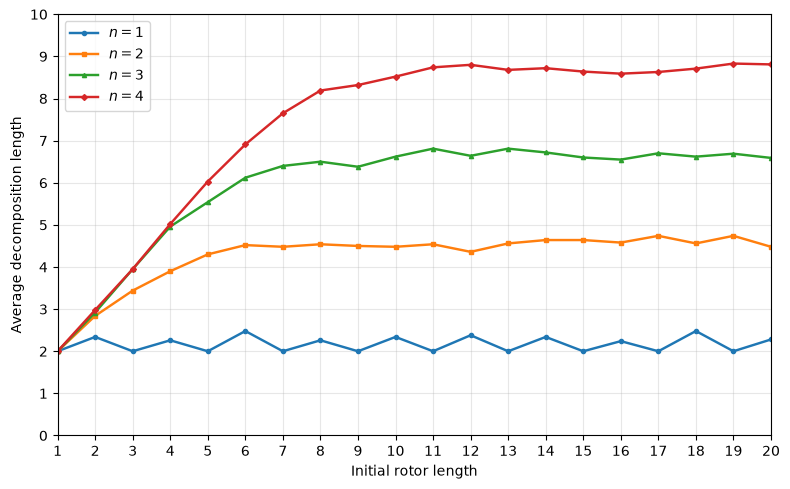

In [ ]:
# === MAIN FIGURE 1: AVERAGE DECOMPOSITION LENGTH ===
# Plot average final rotor count vs initial rotor length, for each dimension n

plt.figure(figsize=(8, 5))

# Different marker for each dimension
markers = {
    1: "o",      # circle for n=1
    2: "s",      # square for n=2
    3: "^",      # triangle for n=3
    4: "D"       # diamond for n=4
}

# Plot one curve per dimension
for n in n_values:
    means = []

    # For each initial length L, compute average final decomposition length
    for L in L_values:
        # Get all trials for this (n, L) combination
        recs = select_records(n=n, L=L)

        # Extract total decomposition lengths (rotor count)
        lengths = [
            r["total_decomposition_length"]
            for r in recs
        ]

        # Compute mean over all trials
        means.append(mean(lengths))

    # Plot the mean curve for this dimension
    plt.plot(
        L_values,
        means,
        marker=markers[n],
        linewidth=1.75,
        markersize=3,
        label=f"$n={n}$"
    )

# Labels and formatting
plt.xlabel("Initial rotor length")
plt.ylabel("Average decomposition length")

plt.xlim(1, 20)
plt.ylim(0, 10)

plt.xticks(range(1, 21))
plt.yticks(range(0, 11))

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save figure
plt.savefig(
    FIG_DIR / "main_figure_1_average_length.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

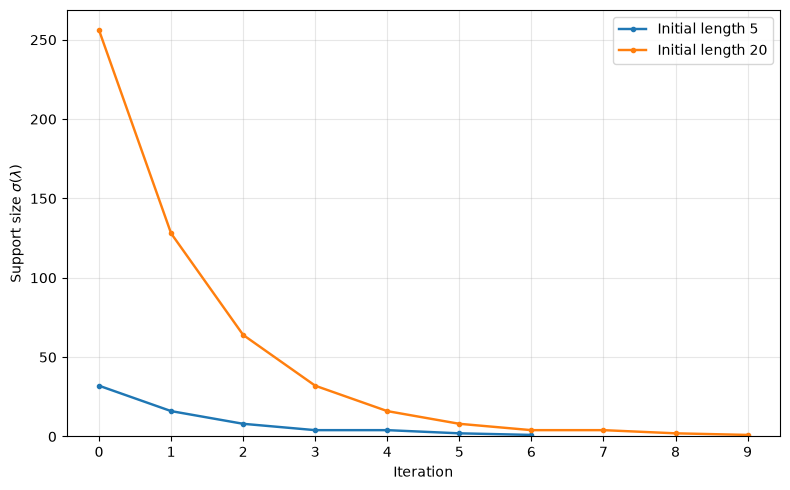

In [ ]:
# === MAIN FIGURE 2: SUPPORT TRAJECTORIES ===
# Show how support size decreases over iterations for example cases

# Select two example runs: one with initial length 5, one with length 20 (both n=4, successful)
examples = []

for target_L in [5, 20]:
    # Find all successful runs with this initial length
    candidates = [
        r for r in data
        if r["n"] == 4
        and r["initial_length"] == target_L
        and r["success"]
    ]

    if candidates:
        # Pick the run with the largest starting support size (most interesting)
        chosen = max(candidates, key=lambda r: r["sigmas"][0])
        examples.append(chosen)

# Create the plot
plt.figure(figsize=(8, 5))

# Plot one trajectory per example
for r in examples:
    sigmas = r["sigmas"]  # Support size at each iteration

    plt.plot(
        range(len(sigmas)),
        sigmas,
        marker="o",
        linewidth=1.75,
        markersize=3,
        label=f"Initial length {r['initial_length']}"
    )

# Labels and formatting
plt.xlabel("Iteration")
plt.ylabel(r"Support size $\sigma(\lambda)$")

# X-axis: iteration numbers (0 to max iterations)
plt.xticks(range(0, max(len(r["sigmas"]) for r in examples)))
plt.ylim(bottom=0)

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save figure
plt.savefig(
    FIG_DIR / "main_figure_2_support_trajectories.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

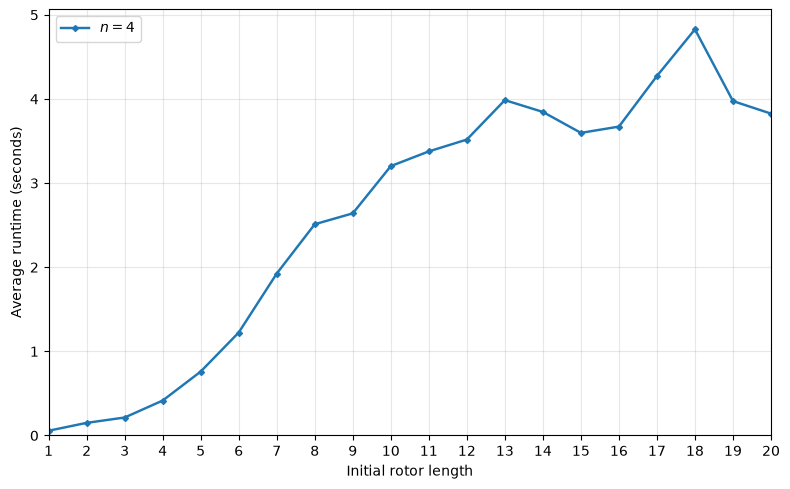

In [ ]:
# === APPENDIX FIGURE A1: RUNTIME SCALING ===
# Plot average execution time vs initial rotor length

plt.figure(figsize=(8, 5))

# Only plot for n=4 (as indicated in the original code)
for n in [4]:
    avg_runtimes = []

    # For each initial length, compute average runtime
    for L in L_values:
        # Get all trials for this (n, L) combination
        recs = select_records(n=n, L=L)
        # Extract runtimes
        runtimes = [r["runtime_seconds"] for r in recs]
        # Compute mean
        avg_runtimes.append(mean(runtimes))

    # Plot the runtime curve
    plt.plot(
        L_values,
        avg_runtimes,
        marker=markers[n],
        linewidth=1.75,
        markersize=3,
        label=f"$n={n}$"
    )

# Labels and formatting
plt.xlabel("Initial rotor length")
plt.ylabel("Average runtime (seconds)")

plt.xlim(1, 20)
plt.xticks(range(1, 21))

plt.ylim(bottom=0)

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save figure
plt.savefig(
    FIG_DIR / "appendix_figure_runtime_scaling.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# === APPENDIX TABLE A1: DETAILED STATISTICS ===
# Generate a comprehensive statistics table for each (n, L) combination

appendix_table = []

# Iterate over all (n, L) pairs
for n in n_values:
    for L in L_values:
        # Get all trials for this pair
        recs = select_records(n=n, L=L)

        # Extract decomposition lengths and success flags
        lengths = [
            r["total_decomposition_length"]
            for r in recs
        ]

        successes = [
            r["success"]
            for r in recs
        ]

        # Compute statistics
        row = {
            "n": n,
            "initial_length": L,
            "mean_length": mean(lengths),      # Average final rotor count
            "std_length": std(lengths),        # Standard deviation
            "max_length": max(lengths),        # Maximum rotor count
            "success_rate": mean(successes)    # Fraction of successful runs
        }

        appendix_table.append(row)

# Save table to JSON
with open("appendix_table_statistics.json", "w") as f:
    json.dump(appendix_table, f, indent=4)

# Print first 10 rows for inspection
for row in appendix_table[:10]:
    print(row)

{'n': 1, 'initial_length': 1, 'mean_length': 2.0, 'std_length': 0.0, 'max_length': 2, 'success_rate': 1.0}
{'n': 1, 'initial_length': 2, 'mean_length': 2.34, 'std_length': 0.9451631252505217, 'max_length': 3, 'success_rate': 1.0}
{'n': 1, 'initial_length': 3, 'mean_length': 2.0, 'std_length': 0.0, 'max_length': 2, 'success_rate': 1.0}
{'n': 1, 'initial_length': 4, 'mean_length': 2.26, 'std_length': 0.9704731741878195, 'max_length': 3, 'success_rate': 1.0}
{'n': 1, 'initial_length': 5, 'mean_length': 2.0, 'std_length': 0.0, 'max_length': 2, 'success_rate': 1.0}
{'n': 1, 'initial_length': 6, 'mean_length': 2.48, 'std_length': 0.8816880045536161, 'max_length': 3, 'success_rate': 1.0}
{'n': 1, 'initial_length': 7, 'mean_length': 2.0, 'std_length': 0.0, 'max_length': 2, 'success_rate': 1.0}
{'n': 1, 'initial_length': 8, 'mean_length': 2.26, 'std_length': 0.9704731741878195, 'max_length': 3, 'success_rate': 1.0}
{'n': 1, 'initial_length': 9, 'mean_length': 2.0, 'std_length': 0.0, 'max_length

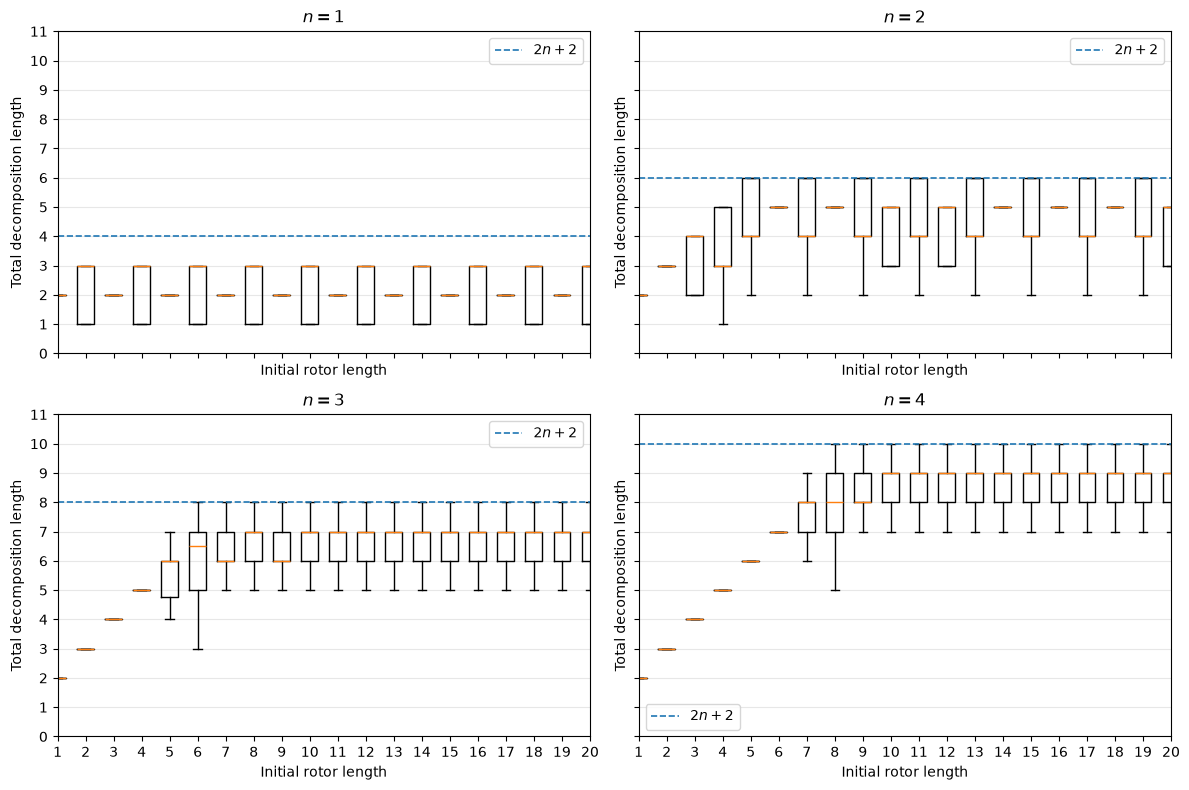

In [ ]:
# === APPENDIX FIGURE A2: DECOMPOSITION LENGTH VARIABILITY ===
# Create a 2x2 grid of boxplots showing the distribution of decomposition lengths
# One subplot for each dimension (n=1,2,3,4)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.ravel()  # Flatten to 1D array for easier indexing

# Create one boxplot per dimension
for ax, n in zip(axes, n_values):
    box_data = []

    # For each initial length L, collect all decomposition lengths
    for L in L_values:
        recs = select_records(n=n, L=L)
        lengths = [
            r["total_decomposition_length"]
            for r in recs
        ]
        box_data.append(lengths)

    # Create boxplot at positions corresponding to L values
    ax.boxplot(
        box_data,
        positions=L_values,  # Position boxes at L values
        widths=0.6,          # Box width
        showfliers=False     # Hide outliers for cleaner visualization
    )

    # Add reference line at y = 2n+2 (theoretical bound if it exists)
    ax.axhline(
        y=2*n + 2,
        linestyle="--",
        linewidth=1.2,
        label=r"$2n+2$"
    )

    # Labels and formatting for this subplot
    ax.set_title(f"$n={n}$")
    ax.set_xlabel("Initial rotor length")
    ax.set_ylabel("Total decomposition length")
    ax.set_xlim(1, 20)
    ax.set_ylim(0, 11)
    ax.set_xticks(range(1, 21))
    ax.set_yticks(range(0, 12))
    ax.grid(True, axis="y", alpha=0.3)
    ax.legend()

# Save the figure
fig.tight_layout()

fig.savefig(
    FIG_DIR / "appendix_figure_length_variability.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()